In [270]:
%pip install numpy matplotlib scipy pandas

Note: you may need to restart the kernel to use updated packages.


In [271]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import pandas as pd
from IPython.display import display
import openpyxl

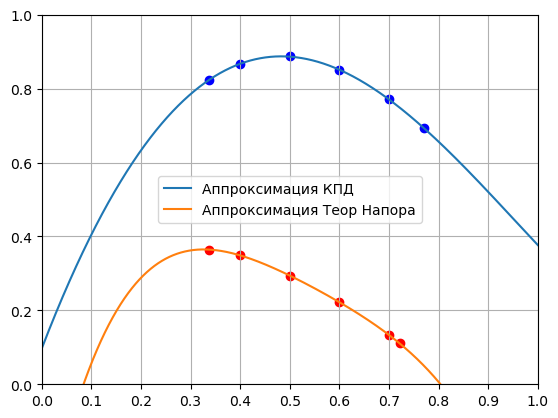

In [272]:
# График с учебника рис. 4

# Точки
x_η_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])       # точки по оси X для теоретического напора
η_dots = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])      # точки по оси Y для теоретического напора

x_Hт_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])    # точки по оси X для КПД
Hт_dots = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721]) # точки по оси Y для КПД

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(x_Hт_dots, Hт_dots, stepen)
poly = np.poly1d(coeffs)
coeffs1 = np.polyfit(x_η_dots, η_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек
x_Hт_dots_smooth = np.linspace(0, 1, smoothness)
Hт_dots_smooth = poly(x_Hт_dots_smooth)
x_η_dots_smooth = np.linspace(0, 1, smoothness)
η_dots_smooth = poly1(x_η_dots_smooth)

plt.plot(x_η_dots_smooth, η_dots_smooth, label="Аппроксимация КПД")
plt.plot(x_Hт_dots_smooth, Hт_dots_smooth, label="Аппроксимация Теор Напора")
plt.scatter(x_Hт_dots, Hт_dots, color="red")
plt.scatter(x_η_dots, η_dots, color="blue")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

Hт_x_line = x_Hт_dots_smooth    # Координаты X для линии теоретического напора
Hт_y_line = Hт_dots_smooth      # Координаты Y для линии теоретического напора
η_x_line = x_η_dots_smooth      # Координаты X для линии КПД
η_y_line = η_dots_smooth        # Координаты Y для линии КПД


# 1. Техническое задание

In [273]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха
c_p = 1006

# 2. Выбор основных параметров компрессора и предварительный расчет проточной части по средней линии тока

## Предварительный расчет проточной части по средней линии тока

In [274]:
d1_отн_start = 0.3
d1_отн_end = 0.6
c_а1_отн_start = 0.45
c_а1_отн_end = 0.65
с_а_отн_start = 0.45
с_а_отн_end = 0.55
Hт_ср_отн_start = 0.1
Hт_ср_отн_end = 0.4
H_т1_start = 0.15
H_т1_end = 0.25

In [275]:
d1_отн = 0.4
c_а1_отн = 0.45
с_а_отн = 0.3
Hт_ср_отн = 0.3
R_ср1 = 0.5
H_т1 = 0.2

# Первое приближение

In [276]:
n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


In [277]:
def a_кр(k, R, T):
    return math.sqrt((2*k/(k+1))*R*T)

def U_k(G_в, n, c_а1_отн, ρ1_полн, d1_отн):
    return math.cbrt((G_в * n**2)/(math.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))

def ε_gdf(k, λ):
    return (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def σ_gdf(ξ, k, ε, λ):
    return (1 / (1 + ξ * (k/(k+1)) * ε * λ**2))

def radius_отн(d_отн):
    return math.sqrt( (1 + d_отн**2) / 2)

def q_gdf(k, λ):
    return ((k+1)/2)**(1/(k-1)) * λ * (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def F_tube(G_в, R_в, T, β, P, q):
    return (G_в * math.sqrt(R_в * T)) / (β * P * q)

In [ ]:
# Определим адиабатический КПД
η_пол = 0.90 # Политропический КПД компрессора из рис.1

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

η_к_полн = ((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1)

# Температура на выходе из ЛА компрессора
Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = a_кр(k, R_в, Tа_полн)
a_кр_вых = a_кр(k, R_в, Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = Pа_полн / (Tа_полн * R_в)

U_k1 = U_k(G_в, n, c_а1_отн, ρ1_полн, d1_отн)

# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = U_k1 * c_а1_отн
c_вых = U_k1 * с_а_отн


# Приведенные скорости в данных сечениях
λ_вх = c_вх / a_кр_вх
λ_вых = c_вых / a_кр_вых

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Определим адиабатический КПД Лопаточного аппарата
π_ла_полн = π_к_полн / (σ_gdf(ξ_вх, k, ε_вх, λ_вх) * σ_gdf(ξ_вых, k, ε_вых, λ_вых))
η_ла_полн = ((π_ла_полн)**((k-1)/k)-1) / ((π_ла_полн)**((k-1)/(k*η_пол))-1)

print(f"""
η_ла_полн = {η_ла_полн:.4f}
η_к_полн  = {η_к_полн:.4f}
""")


η_ла_полн = 0.8828
η_к_полн  = 0.8829



In [279]:
# Пренебрегая теплообменом в трубках:
T1_полн = Tа_полн

# Температура на выходе из ЛА компрессора
Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = a_кр(k, R_в, Tа_полн)
a_кр_вых = a_кр(k, R_в, Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = Pа_полн / (Tа_полн * R_в)

# Окружная скорость конца рабочей лопатки
U_k1 = U_k(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
print(f"U_k1 = {U_k1:.2f} м/с")

for i in range(3):      # Цикл для трех приближений
    # Осевая скорость на переферии РК
    c_а1 = c_а1_отн * U_k(G_в, n, c_а1_отн, ρ1_полн, d1_отн)

    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = U_k1 * c_а1_отн
    c_вых = U_k1 * с_а_отн

    # Приведенные скорости в данных сечениях
    λ_вх = c_вх / a_кр_вх
    λ_вых = c_вых / a_кр_вых

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = ε_gdf(k, λ_вх)
    ε_вых = ε_gdf(k, λ_вых)

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_gdf(ξ_вх, k, ε_вх, λ_вх)
    σ_вых = σ_gdf(ξ_вых, k, ε_вых, λ_вых)

    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн

    # Средний радиус на входе в первую степень
    r_ср1_отн = radius_отн(d1_отн)

    # Безразмерная окружная составляющая абсолютной скорости на входе
    c_1u_отн = r_ср1_отн * (1 - R_ср1) - (H_т1 / (2 * r_ср1_отн))

    # Абсолютная скорость: 
    c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

    # Приведенная скорость:
    λ1 = c1 / a_кр_вх

    # ГДФ плотности
    ε = (1 - ((k-1)/(k+1)) * λ1**2)**(1/(k-1))

    # Плотность рабочего тела перед РК
    ρ1 = (P1_полн / (R_в * T1_полн)) * ε

    # Перерасчет окружной скорости конца рабочей лопатки
    U_k1 = U_k(G_в, n, c_а1_отн, ρ1, d1_отн)
    print(f"U_k1 = {U_k1:.2f} м/с")

U_k1 = 319.97 м/с
U_k1 = 333.63 м/с
U_k1 = 334.88 м/с
U_k1 = 335.00 м/с


In [280]:
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = U_k1 * c_а1_отн
c_вых = U_k1 * с_а_отн

# Приведенные скорости в данных сечениях
λ_вх = c_вх / a_кр_вх
λ_вых = c_вых / a_кр_вых

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = (1 / (1 + ξ_вх * (k/(k+1)) * ε_вх * λ_вх**2))
σ_вых = (1 - ξ_вых * (k/(k+1)) * ε_вых * λ_вых**2)

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
P2_полн = Pа_полн * π_к_полн / σ_вых

# Степень повышения полного давления лопаточного аппарата
π_ла_полн = P2_полн / P1_полн
π_к_полн = π_ла_полн * (σ_вых * σ_вх)

# КПД лопаточного аппарата
η_ла = σ_вых * σ_вх  # Должно быть 1

# Коэффициент C определяется из графика на рис. 7
C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
# !!!!!!!!
# !!!!!!!!

η_ла_полн = η_к_полн / C
η_к_полн = η_ла_полн * ((π_к_полн**((k-1)/k)-1)/(π_ла_полн**((k-1)/k)-1))


β = math.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))

# Приведенная плотность потока массы
q_вх = q_gdf(k, λ_вх)
q_вых = q_gdf(k, λ_вых)
# Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
F_вх = F_tube(G_в, R_в, T1_полн, β, P1_полн, q_вх)
F_вых = F_tube(G_в, R_в, T2_полн, β, P2_полн, q_вых)

# Наружный диаметр ротора:
D_к1 = 2 * U_k1 / n

# Внутренний диаметр
D_вт1 = D_к1 * d1_отн

# Средний диаметр
D_ср1 = D_к1 * r_ср1_отн

# Высота лопатки РК 1-й ступени:
h_1 = (1/2) * D_к1 * (1 - d1_отн)

# Диаметр втулки лопаток последнйей ступени:
D_вт_n = math.sqrt(D_к1**2 - ((4 * F_вых) / math.pi))

# Относительный диаметр втулки рабочего колеса последней ступени:
d_n_отн = D_вт_n / D_к1

# Высота лопаток последней ступени:
h_n = (1/2) * D_к1 * (1 - d_n_отн)

# Окружная скорость концов рабочих лопаток "средней" ступени:
# Теоретический напор "средней" ступени:
Hт_ср = Hт_ср_отн * (U_k1**2)

# Адиабатический напор компрессора по параметрам затарможенного потока
H_ад_к_полн = (k*R_в)/(k-1) * Tа_полн*((π_к_полн ** ((k-1)/k))-1)

# Сумма теоретических напоров по ступеням:
H_тк = H_ад_к_полн / η_к_полн

# Число ступеней компрессора:
z = H_тк / Hт_ср
print(f"z = {z} Не округленное")

z = math.ceil(z)
print(f"z = {z}")

print(f"η_ла = {η_ла}")
print(f"π_к_полн = {π_к_полн}")

z = 12.392299547954384 Не округленное
z = 13
η_ла = 0.99019899738749
π_к_полн = 18.200000000000003


In [281]:
print(f"""
η_пол = {η_пол:.3f} - политропический КПД компрессора
η_к_полн = {η_к_полн:.4f} - адиабатический КПД компрессора

T1_полн = {T1_полн:.2f} K - температура на входе в ЛА
Tk_полн = {Tk_полн:.2f} K - температура на выходе из ЛА
T2_полн = {T2_полн:.2f} K - температура на входе в следующий элемент

a_кр_вх = {a_кр_вх:.2f} м/с - критическая скорость звука во входном патрубке
a_кр_вых = {a_кр_вых:.2f} м/с - критическая скорость звука в выходном патрубке

ρ1_полн = {ρ1_полн:.4f} кг/м³ - плотность по заторможенным параметрам

U_k1 = {U_k1:.2f} м/с - окружная скорость конца рабочей лопатки

c_а1 = {c_а1:.2f} м/с - осевая скорость на периферии РК
c_вх = {c_вх:.2f} м/с - абсолютная скорость на входе во входной патрубок
c_вых = {c_вых:.2f} м/с - абсолютная скорость на выходе из выходного патрубка

λ_вх = {λ_вх:.4f} - приведённая скорость во входном патрубке
λ_вых = {λ_вых:.4f} - приведённая скорость в выходном патрубке

ξ_вх = {ξ_вх:.3f} - коэффициент потерь полного давления во входном патрубке
ξ_вых = {ξ_вых:.3f} - коэффициент потерь полного давления в выходном патрубке

ε_вх = {ε_вх:.4f} - ГДФ плотности во входном патрубке
ε_вых = {ε_вых:.4f} - ГДФ плотности в выходном патрубке

σ_вх = {σ_вх:.4f} - коэффициент сохранения полного давления во входном патрубке
σ_вых = {σ_вых:.4f} - коэффициент сохранения полного давления в выходном патрубке

P1_полн = {P1_полн:.2f} Па - полное давление на входе в РК

r_ср1_отн = {r_ср1_отн:.4f} - относительный средний радиус на входе в первую ступень

c_1u_отн = {c_1u_отн:.4f} - безразмерная окружная составляющая абсолютной скорости

c1 = {c1:.2f} м/с - абсолютная скорость перед РК
λ1 = {λ1:.4f} - приведённая скорость перед РК

ε = {ε:.4f} - ГДФ плотности перед РК

ρ1 = {ρ1:.4f} кг/м³ - плотность рабочего тела перед РК
""")

print(f"""
c_вх = {c_вх:.2f} м/с - абсолютная скорость на выходе из входного патрубка
c_вых = {c_вых:.2f} м/с - абсолютная скорость на входе в выходной патрубок

λ_вх = {λ_вх:.4f} - приведённая скорость во входном патрубке
λ_вых = {λ_вых:.4f} - приведённая скорость в выходном патрубке

ξ_вх = {ξ_вх:.3f} - коэффициент потерь полного давления во входном патрубке
ξ_вых = {ξ_вых:.3f} - коэффициент потерь полного давления в выходном патрубке

ε_вх = {ε_вх:.4f} - ГДФ плотности во входном патрубке
ε_вых = {ε_вых:.4f} - ГДФ плотности в выходном патрубке

σ_вх = {σ_вх:.4f} - коэффициент сохранения полного давления во входном патрубке
σ_вых = {σ_вых:.4f} - коэффициент сохранения полного давления в выходном патрубке

P1_полн = {P1_полн:.2f} Па - полное давление на входе в лопаточный аппарат
P2_полн = {P2_полн:.2f} Па - полное давление на выходе из лопаточного аппарата

π_ла_полн = {π_ла_полн:.4f} - степень повышения полного давления в ЛА
π_к_полн = {π_к_полн:.4f} - степень повышения полного давления компрессора

η_ла = {η_ла:.4f} - КПД лопаточного аппарата
η_ла_полн = {η_ла_полн:.4f} - полный КПД лопаточного аппарата
η_к_полн = {η_к_полн:.4f} - полный КПД компрессора

C = {C:.3f} - коэффициент из графика

β = {β:.4f} - коэффициент расходной функции

q_вх = {q_вх:.4f} - приведённая плотность потока массы во входном патрубке
q_вых = {q_вых:.4f} - приведённая плотность потока массы в выходном патрубке

F_вх = {F_вх:.5f} м² - кольцевая площадь на выходе из входного патрубка
F_вых = {F_вых:.5f} м² - кольцевая площадь на входе в выходной патрубок

D_к1 = {D_к1:.4f} м - наружный диаметр ротора
D_вт1 = {D_вт1:.4f} м - внутренний диаметр ротора
D_ср1 = {D_ср1:.4f} м - средний диаметр

h_1 = {h_1:.4f} м - высота лопаток первой ступени

D_вт_n = {D_вт_n:.4f} м - диаметр втулки последней ступени
d_n_отн = {d_n_отн:.4f} - относительный диаметр втулки последней ступени

h_n = {h_n:.4f} м - высота лопаток последней ступени

Hт_ср = {Hт_ср:.2f} Дж/кг - теоретический напор средней ступени

H_ад_к_полн = {H_ад_к_полн:.2f} Дж/кг - адиабатический напор компрессора

H_тк = {H_тк:.2f} Дж/кг - суммарный теоретический напор по ступеням

z = {z} - число ступеней компрессора
""")


η_пол = 0.920 - политропический КПД компрессора
η_к_полн = 0.8964 - адиабатический КПД компрессора

T1_полн = 288.00 K - температура на входе в ЛА
Tk_полн = 709.12 K - температура на выходе из ЛА
T2_полн = 709.12 K - температура на входе в следующий элемент

a_кр_вх = 310.75 м/с - критическая скорость звука во входном патрубке
a_кр_вых = 487.61 м/с - критическая скорость звука в выходном патрубке

ρ1_полн = 1.2239 кг/м³ - плотность по заторможенным параметрам

U_k1 = 335.00 м/с - окружная скорость конца рабочей лопатки

c_а1 = 143.99 м/с - осевая скорость на периферии РК
c_вх = 150.75 м/с - абсолютная скорость на входе во входной патрубок
c_вых = 100.50 м/с - абсолютная скорость на выходе из выходного патрубка

λ_вх = 0.4851 - приведённая скорость во входном патрубке
λ_вых = 0.2061 - приведённая скорость в выходном патрубке

ξ_вх = 0.050 - коэффициент потерь полного давления во входном патрубке
ξ_вых = 0.150 - коэффициент потерь полного давления в выходном патрубке

ε_вх = 0.9048 - ГД

# 3. Поступенчатый расчет компрессора по средней линии тока

In [282]:
N = z   # Число ступеней компрессора
N_list = np.linspace(1, N, N)   # Массив от 1 до N для итерации по ступеням

Hт_x_result = []
Hт_отн_result = []

c_a_отн = np.linspace(c_а1_отн, с_а_отн, N) # Линейно изменяющийся коэффициент расхода от первой до последней ступени

In [283]:
def find_nearest(c_a_отн, x_line, y_line):
    x_result = []
    y_result = []

    for i in range(len(c_a_отн)):
        index = np.abs(x_line - c_a_отн[i]).argmin() # Находим индекс ближайшего значения в x_line к c_a_отн[i]
        x_result.append(x_line[index])    # Добавляем найденное значение в результат
        y_result.append(y_line[index])  # Добавляем соответствующее значение y_line в результат
    return x_result, y_result

Hт_x_result, Hт_отн_result = find_nearest(c_a_отн, Hт_x_line, Hт_y_line)
η_x_result, η_ад_полн_result = find_nearest(c_a_отн, η_x_line, η_y_line)

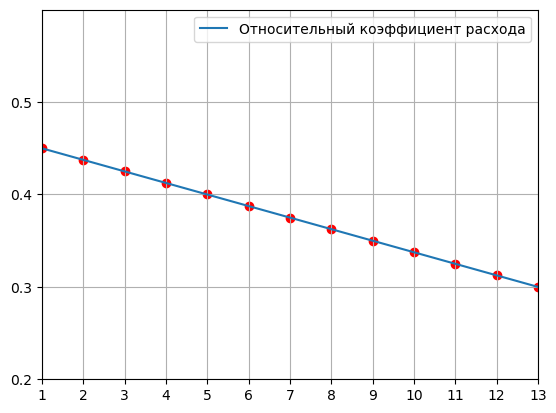

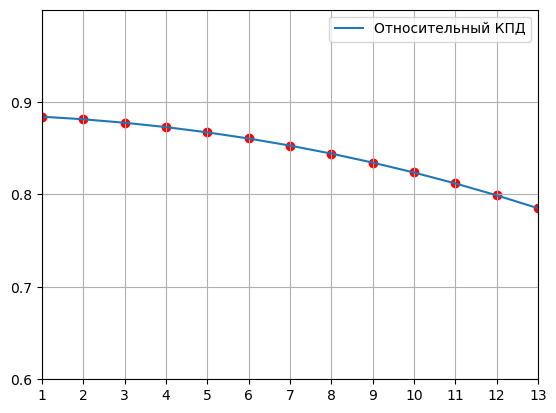

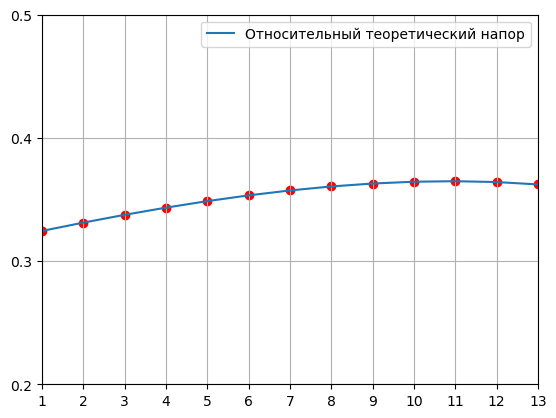

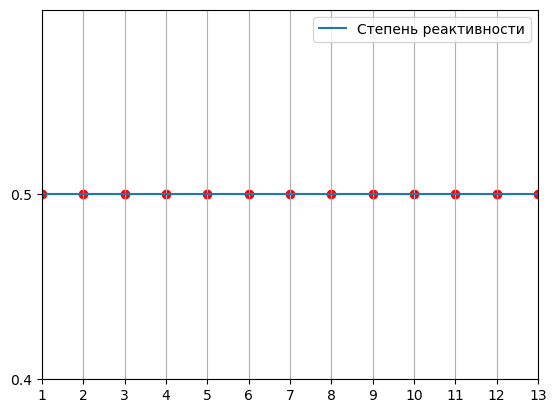

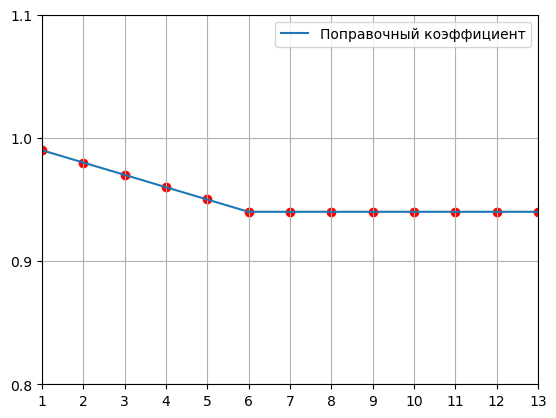

In [284]:
def plot_results(x, y, label_name):
    ylim_min = math.floor(min(y)*10)/10-0.1
    ylim_max = math.ceil(max(y)*10)/10+0.1
    plt.plot(x, y, label=label_name)
    plt.scatter(x, y, color="red")
    plt.xlim(1,max(x))
    plt.ylim(ylim_min, ylim_max)
    plt.xticks(np.arange(1, max(x)+1, 1))
    plt.yticks(np.arange(ylim_min, ylim_max, 0.1))
    plt.grid(True) # Добавление сетки
    plt.legend()
    plt.show()

R_ср1_list = np.linspace(R_ср1, R_ср1, N)  # Создаем массив из N элементов, все равные R_ср1
Kh = np.concatenate([
    np.linspace(0.99, 0.94, 6),
    np.full((N-6), 0.94)
])

plot_results(N_list, c_a_отн, "Относительный коэффициент расхода")
plot_results(N_list, η_ад_полн_result, "Относительный КПД")
plot_results(N_list, Hт_отн_result, "Относительный теоретический напор")
plot_results(N_list, R_ср1_list, "Степень реактивности")
plot_results(N_list, Kh, "Поправочный коэффициент")

In [285]:
# Расчет ВНА
# Коэффициент сохранения полного давления в ВНА
print(f"""
    σ_вх = {σ_вх:.4f} - коэффициент сохранения полного давления в ВНА
    Pa_полн = {Pа_полн:.2f} Па - полное давление на входе в ВНА
    P1_полн = {P1_полн:.2f} Па - полное давление на выходе из ВНА
    c_1u_отн = {c_1u_отн:.4f} - безразмерная окружная составляющая абсолютной скорости на выходе из ВНА""")

# Направление абсолютной скорости на входе в ВНА
α_1_вна = math.radians(90)
α_2_вна = (math.atan(c_а1_отн / c_1u_отн))

print(f"""
    α_1_вна = {math.degrees(α_1_вна):.2f}° - направление абсолютной скорости на входе в ВНА
    α_2_вна = {math.degrees(α_2_вна):.2f}° - направление абсолютной скорости на выходе из ВНА
      """)


    σ_вх = 0.9938 - коэффициент сохранения полного давления в ВНА
    Pa_полн = 101300.00 Па - полное давление на входе в ВНА
    P1_полн = 100674.77 Па - полное давление на выходе из ВНА
    c_1u_отн = 0.2495 - безразмерная окружная составляющая абсолютной скорости на выходе из ВНА

    α_1_вна = 90.00° - направление абсолютной скорости на входе в ВНА
    α_2_вна = 61.00° - направление абсолютной скорости на выходе из ВНА
      


# Создание пустых списков для записи в них значений

In [286]:
c_a_отн_i_list = [] 
c_a_отн_i_plus_1_list = []  
Kh_i_list = []  
η_ад_полн_i_list = []  
d1_отн_i_list = []  
ρ1_i_list = [] 
U_k1_i_list = [] 
Hт_отн_i_list = []
T1_полн_i_list = []  
P1_полн_i_list = [] 
Hт_i_list = []  
L_z_i_list = []  
H_ад_i_list = [] 
ΔT_полн_i_list = [] 
T3_полн_i_list = []   
T1_полн_i_plus_1_list = [] 
π_полн_i_list = []  
P3_полн_i_list = []
P1_полн_i_plus_1_list = []  
a_кр_1_i_list = []    
a_кр_3_i_list = []  
r_ср1_отн_i_list = [] 
c_u1_отн_i_list = []  
α_1_i_list = []  
c_a1_i_list = []  
λ_1_i_list = []  
q_1_i_list = []  
F_1_i_list = []  
c_a3_отн_i_list = []  
c_a3_i_list = []  
λ_3_отн_i_list = []  
q_3_отн_i_list = []  
F_3_отн_i_list = []  
D_вт3_i_list = []  
d3_отн_i_list = []  
r_ср3_отн_i_list = []  
c_3u_отн_i_list = []  
α_3_отн_i_list = []  
λ_3_i_list = []  
q_3_i_list = []  
F_3_i_list = []  
r_ср2_отн_i_list = []  
c_u2_отн_i_list = []  
β_1_i_list = []  
c_a2_отн_i_list = []  
β_2_i_list = []  
α_2_i_list = []  
ε_рк_i_list = []  
α_3_i_list = []  
ε_на_i_list = []  
c_1_i_list = []  
ρ3_i_list = []  
W_1_i_list = []  
c_a2_i_list = []  
W_2_i_list = []  
c_2_i_list = []  
τ_1_i_list = []  
T_1_i_list = []  
a_1_i_list = []  
M_w1_i_list = []  
λ_c2_i_list = []  
T2_полн_i_list = []  
τ_2_i_list = []  
T_2_i_list = []  
a_2_i_list = []  
M_c2_ср_i_list = []  
D_вт1_i_list = []  
h_рк_i_list = []  
d2_отн_i_list = []  
D_ср_1_list = []  
D_ср_2_list = []  
D_ср_3_list = []  
D_вт2_i_list = []  
h_на_i_list = []  
h_на_3_i_list = [] 

In [287]:
for i in range(0, N, 1):
    c_a_отн_i = c_a_отн[i]  # Коэффициент расхода на входе в ступень
    if i != (N-1):
        c_a_отн_i_plus_1 = c_a_отн[i+1] # Коэффициент расхода на выходе из ступени
    else:
        c_a_отн_i_plus_1 = c_a_отн[i] # Коэффициент расхода на выходе из ступени
    Kh_i = Kh[i]    # Поправочный коэффициент для i-й ступени
    η_ад_полн_i = η_ад_полн_result[i]   # Адиабатический КПД для i-й ступени
    d1_отн_i = d1_отн   # Относительный диаметр для i-й ступени
    ρ1_i = ρ1   # Плотность для i-й ступени
    U_k1_i = math.cbrt((G_в * n**2)/(math.pi * c_а1_отн * ρ1 * (1 - d1_отн**2)))    # Окружная скорость для i-й ступени
    Hт_отн_i = Hт_отн_result[i]  # Относительный теоретический напор для i-й ступени
    if i == 0: 
        T1_полн_i = T1_полн # Температура на входе в первую ступень
        P1_полн_i = P1_полн
    else:
        T1_полн_i = T1_полн_i_plus_1 # Температура на входе в i-ю ступень
        P1_полн_i = P1_полн_i_plus_1 # Полное давление на входе в i-ю ступень
        
        
    # Теоретический напор для i-й ступени:
    Hт_i = Hт_отн_i * (U_k1_i**2)
    
    # Действительная работа сжатия для i-й ступени:
    L_z_i = Kh_i * Hт_i
    
    # Адиабатическая работа сжатия для i-й ступени:
    H_ад_i = L_z_i * η_ад_полн_i
    
    # Повышение полной температуры в ступени:
    ΔT_полн_i = L_z_i / c_p # с_р в каждой ступени разный т.к. меняется температура
    
    # Полная температура на выходе из ступени:
    T3_полн_i = T1_полн_i + ΔT_полн_i
    T1_полн_i_plus_1 = T3_полн_i    # Температура на выходе становится температурой на входе в следующую ступень
    
    # Степень повышения полного давления:
    π_полн_i = (1 + (H_ад_i / (c_p * T1_полн_i)))**(k/(k-1))
    
    # Полное давление на выходе из ступени:
    P3_полн_i = P1_полн_i * π_полн_i 
    P1_полн_i_plus_1 = P3_полн_i    # Полное давление на выходе становится полным давлением на входе в следующую ступень
    
    # Критическая скорость потока на входе и выходе:
    a_кр_1_i = math.sqrt((2*k/(k+1))*R_в*T1_полн_i)
    a_кр_3_i = math.sqrt((2*k/(k+1))*R_в*T3_полн_i)
    
    # Средний радиус на входе в i-ю ступень:
    r_ср1_отн_i = math.sqrt( (1 + d1_отн_i**2) / 2)
    
    # Безразмерная окружная составляющая абсолютной скорости на входе в i-ю ступень:
    c_u1_отн_i = r_ср1_отн_i * (1 - R_ср1_list[i]) - (Hт_отн_i / (2 * r_ср1_отн_i))
    
    # Направление абсолютной скорости на входе
    α_1_i = α_2_вна
    
    # Приведенная скорость на входе
    c_a1_i = c_a_отн_i * U_k1_i
    λ_1_i = c_a1_i / (math.sin(α_1_i) * a_кр_1_i)
    
    # ГДФ расхода
    q_1_i = ((k+1)/2)**(1/(k-1)) * λ_1_i * (1 - (k-1)/(k+1)*λ_1_i**2)**(1/(k-1))
    
    # Кольцевая площадь на входе в ступень
    F_1_i = (G_в * math.sqrt(R_в * T1_полн_i)) / (β * P1_полн_i * q_1_i * math.sin(α_1_i))

    # Кольцевая площадь на выходе из ступени F3
    c_a3_отн_i = c_a_отн_i_plus_1
    c_a3_i = c_a3_отн_i * U_k1_i
    λ_3_отн_i = c_a3_i / (math.sin(α_1_i) * a_кр_3_i)
    q_3_отн_i = ((k+1)/2)**(1/(k-1)) * λ_3_отн_i * (1 - (k-1)/(k+1)*λ_3_отн_i**2)**(1/(k-1))
    F_3_отн_i = F_1_i * ((q_1_i * P1_полн_i) / (q_3_отн_i * P3_полн_i)) * math.sqrt(T3_полн_i / T1_полн_i)
    
    # Относительный диаметр втулки на выходе из ступени d3отн в первом прибляж для принятой ф. проточной части Dk = const
    # D.вт3 - диаметр периферии на выходе из i ступени
    D_вт3_i = math.sqrt(D_к1**2 - ((4 * F_3_отн_i) / math.pi))
    d3_отн_i = D_вт3_i / D_к1
    r_ср3_отн_i = math.sqrt( (1 + d3_отн_i**2) / 2)
    
    # Окружная состовляющая абсолютной скорости на выходе
    if i != (N-1):
        c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_list[i+1]) - (Hт_отн_result[i+1] / (2 * r_ср3_отн_i))
    else:
        c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_list[i]) - (Hт_отн_result[i] / (2 * r_ср3_отн_i))
    
    # Направление абсолютной скорости на выходе
    α_3_отн_i = math.atan(c_a3_отн_i / c_3u_отн_i)

    # Приведенная скорость на выходе
    λ_3_i = c_a3_i / (math.sin(α_3_отн_i) * a_кр_3_i)
    
    # Действительная кольцевая площадь на выходе из ступени
    q_3_i = ((k+1)/2)**(1/(k-1)) * λ_3_i * (1 - (k-1)/(k+1)*λ_3_i**2)**(1/(k-1))
    F_3_i = F_3_отн_i * (q_3_отн_i / q_3_i)
    
    # Действительный отн. диаметр втулки на выходе из ступени для Dk=const
    D_вт3_i = math.sqrt(D_к1**2 - ((4 * F_3_i) / math.pi))
    d3_отн_i = D_вт3_i / D_к1
    
    # Относительный средний радиус на выходе из ступени
    r_ср3_отн_i = math.sqrt( (1 + d3_отн_i**2) / 2)
    
    # Окружная состовляющая абсолютной скорости на выходе

    if i != (N-1):
        c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_list[i+1]) - (Hт_отн_result[i+1] / (2 * r_ср3_отн_i))
    else:
        c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_list[i]) - (Hт_отн_result[i] / (2 * r_ср3_отн_i))
    # Относительный средний радиус на выходе из рабочего колеса
    r_ср2_отн_i = (r_ср1_отн_i + r_ср3_отн_i) / 2
    
    # Безразмерная окружная составляющая абсолютной скорости на выходе из рабочего колеса
    c_u2_отн_i = (1 / r_ср2_отн_i) * (Hт_отн_i + c_u1_отн_i * r_ср1_отн_i)
    
    # Углы потока в относительном движении
    β_1_i = math.atan((c_a_отн_i / (r_ср1_отн_i- c_u1_отн_i)))
    c_a2_отн_i = (c_a_отн_i + c_a_отн_i_plus_1) / 2
    β_2_i = math.atan((c_a2_отн_i / (r_ср2_отн_i- c_u2_отн_i)))
    
    # Направление потока в абсолютном движении после рабочего колеса
    α_2_i = math.atan(c_a2_отн_i / c_u2_отн_i)
    
    # Углы поворота потока в средних сечениях лопаток РК и НА
    ε_рк_i = β_2_i - β_1_i
    
    # Направление потока в абсолютном движении после НА
    α_3_i = math.atan(c_a3_отн_i / c_3u_отн_i)
    ε_на_i = α_3_i - α_2_i
    λ_3_i = c_a3_i / (math.sin(α_3_i) * a_кр_3_i)
    
    # Абсолютная скорость на входе в РК
    c_1_i = U_k1_i * math.sqrt(c_a_отн_i**2 + c_u1_отн_i**2)
    
    # Плотность заторможенного потока на выходе из ступени
    ε_3_i = (1 - (k-1)/(k+1)*λ_3_i**2)**(1/(k-1))
    ρ3_i = ((P3_полн_i) / (R_в * T3_полн_i)) * ε_3_i
    
    # Относительная скорость на среднем радиусе на входе в РК
    W_1_i = c_a1_i / math.sin(β_1_i)
    c_a2_i = c_a2_отн_i * U_k1_i
    
    # Относительная скорость на среднем радиусе на входе в НА
    W_2_i = c_a2_i / math.sin(β_2_i)
    
    # Абсолютная скорость на среднем радиусе на входе в НА
    c_2_i = c_a2_i / math.sin(α_2_i)
    
    # ГДФ температуры на входе в РК
    τ_1_i = (1 - (λ_1_i**2)*((k-1)/(k+1)))
    
    
    # Статическая температура перед РК
    T_1_i = T1_полн_i * τ_1_i
    
    # Скорость звука на входе в РК
    a_1_i = math.sqrt(k * R_в * T_1_i)
    
    # Число Маха по относительной скорости на входе в РК
    M_w1_i = W_1_i / a_1_i
    
    # Приведенная скорость перед НА
    λ_c2_i = c_2_i / a_кр_3_i
    
    # Статическая температура перед НА
    T2_полн_i = T3_полн_i
    τ_2_i = (1 - (λ_c2_i**2)*((k-1)/(k+1)))
    T_2_i = T2_полн * τ_2_i
    
    # Скорость звука на входе в НА
    a_2_i = math.sqrt(k * R_в * T_2_i)
    
    # Число Маха по абсолютной скорости на входе в НА
    M_c2_ср_i = c_2_i / a_2_i
    
    # Высота лопаток рабочего колеса
    D_вт1_i = D_к1 * d1_отн_i
    h_рк_i = 0.5 * (D_к1 - D_вт1_i)
    
    # Относительный диаметр втулки на выходе из РК
    d2_отн_i = math.sqrt(2 * (r_ср2_отн_i**2) - 1)
    D_ср_1 = D_к1 * r_ср1_отн_i
    D_ср_2 = D_к1 * r_ср2_отн_i
    D_ср_3 = D_к1 * r_ср3_отн_i
    
    # Периферийный диаметр на выходе из РК
    D_вт2_i = D_к1 * d2_отн_i
    D_вт1_i = D_к1 * d1_отн_i
    
    # Высота лопаток НА
    h_на_i = 0.5 * (D_к1 - D_вт2_i)
    h_на_3_i = 0.5 * (D_к1 - D_вт3_i)

    # Сохранение всех значений ниже
    c_a_отн_i_list.append(c_a_отн_i)  
    c_a_отн_i_plus_1_list.append(c_a_отн_i_plus_1)  
    Kh_i_list.append(Kh_i)  
    η_ад_полн_i_list.append(η_ад_полн_i)  
    d1_отн_i_list.append(d1_отн_i)  
    ρ1_i_list.append(ρ1_i)  
    U_k1_i_list.append(U_k1_i)  
    Hт_отн_i_list.append(Hт_отн_i)  
    T1_полн_i_list.append(T1_полн_i)  
    P1_полн_i_list.append(P1_полн_i)  
    Hт_i_list.append(Hт_i)  
    L_z_i_list.append(L_z_i)  
    H_ад_i_list.append(H_ад_i)  
    ΔT_полн_i_list.append(ΔT_полн_i)  
    T3_полн_i_list.append(T3_полн_i)  
    T1_полн_i_plus_1_list.append(T1_полн_i_plus_1)  
    π_полн_i_list.append(π_полн_i)  
    P3_полн_i_list.append(P3_полн_i)  
    P1_полн_i_plus_1_list.append(P1_полн_i_plus_1)  
    a_кр_1_i_list.append(a_кр_1_i)  
    a_кр_3_i_list.append(a_кр_3_i)  
    r_ср1_отн_i_list.append(r_ср1_отн_i)  
    c_u1_отн_i_list.append(c_u1_отн_i)  
    α_1_i_list.append(α_1_i)  
    c_a1_i_list.append(c_a1_i)  
    λ_1_i_list.append(λ_1_i)  
    q_1_i_list.append(q_1_i)  
    F_1_i_list.append(F_1_i)  
    c_a3_отн_i_list.append(c_a3_отн_i)  
    c_a3_i_list.append(c_a3_i)  
    λ_3_отн_i_list.append(λ_3_отн_i)  
    q_3_отн_i_list.append(q_3_отн_i)  
    F_3_отн_i_list.append(F_3_отн_i)  
    D_вт3_i_list.append(D_вт3_i)  
    d3_отн_i_list.append(d3_отн_i)  
    r_ср3_отн_i_list.append(r_ср3_отн_i)  
    c_3u_отн_i_list.append(c_3u_отн_i)  
    α_3_отн_i_list.append(α_3_отн_i)  
    λ_3_i_list.append(λ_3_i)  
    q_3_i_list.append(q_3_i)  
    F_3_i_list.append(F_3_i)  
    r_ср2_отн_i_list.append(r_ср2_отн_i)  
    c_u2_отн_i_list.append(c_u2_отн_i)  
    β_1_i_list.append(β_1_i)  
    c_a2_отн_i_list.append(c_a2_отн_i)  
    β_2_i_list.append(β_2_i)  
    α_2_i_list.append(α_2_i)  
    ε_рк_i_list.append(ε_рк_i)  
    α_3_i_list.append(α_3_i)  
    ε_на_i_list.append(ε_на_i)  
    c_1_i_list.append(c_1_i)  
    ρ3_i_list.append(ρ3_i)  
    W_1_i_list.append(W_1_i)  
    c_a2_i_list.append(c_a2_i)  
    W_2_i_list.append(W_2_i)  
    c_2_i_list.append(c_2_i)  
    τ_1_i_list.append(τ_1_i)  
    T_1_i_list.append(T_1_i)  
    a_1_i_list.append(a_1_i)  
    M_w1_i_list.append(M_w1_i)  
    λ_c2_i_list.append(λ_c2_i)  
    T2_полн_i_list.append(T2_полн_i)  
    τ_2_i_list.append(τ_2_i)  
    T_2_i_list.append(T_2_i)  
    a_2_i_list.append(a_2_i)  
    M_c2_ср_i_list.append(M_c2_ср_i)  
    D_вт1_i_list.append(D_вт1_i)  
    h_рк_i_list.append(h_рк_i)  
    d2_отн_i_list.append(d2_отн_i)  
    D_ср_1_list.append(D_ср_1)  
    D_ср_2_list.append(D_ср_2)  
    D_ср_3_list.append(D_ср_3)  
    D_вт2_i_list.append(D_вт2_i)  
    h_на_i_list.append(h_на_i)  
    h_на_3_i_list.append(h_на_3_i)

In [288]:
# Степень повышения полного давления в лопаточном аппарате:
π_ла_полн = P3_полн_i_list[len(P3_полн_i_list)-1] / P1_полн_i_list[0]
η_ла_полн = ((T1_полн_i_list[0] * ((π_ла_полн ** ((k-1)/k)) - 1)) / (T3_полн_i_list[len(T3_полн_i_list)-1] - T1_полн_i_list[0]))

# Степень повышения полного давления в компрессоре
π_к_полн = π_ла_полн * (1 / (1 + ξ_вх * (k/(k+1)) * ε_вх * λ_вх**2)) * (1 - ξ_вых * (k/(k+1)) * ε_вых * λ_вых**2)

# КПД компрессора
η_к_полн = ((T1_полн_i_list[0] * ((π_к_полн ** ((k-1)/k)) - 1)) / (T3_полн_i_list[len(T3_полн_i_list)-1] - T1_полн_i_list[0]))

print(f"""
π_ла_полн = {π_ла_полн:.4f}
η_ла_полн = {η_ла_полн:.4f}

π_к_полн = {π_к_полн:.4f}
η_к_полн = {η_к_полн:.4f}
""")


π_ла_полн = 19.4298
η_ла_полн = 0.7918

π_к_полн = 19.2393
η_к_полн = 0.7879



### начало для создания итераций кода
### переменные, по которым определяется лучший расчет
π_к_полн
η_к_полн


# 4. Результаты расчета в среднем сечении

In [289]:
# Список всех имён переменных‑списков
list_names = [
    "c_a_отн_i_list","c_a_отн_i_plus_1_list","Kh_i_list",
    "η_ад_полн_i_list","d1_отн_i_list","ρ1_i_list","U_k1_i_list",
    "Hт_отн_i_list","T1_полн_i_list","P1_полн_i_list","Hт_i_list",
    "L_z_i_list","H_ад_i_list","ΔT_полн_i_list","T3_полн_i_list",
    "T1_полн_i_plus_1_list","π_полн_i_list","P3_полн_i_list",
    "P1_полн_i_plus_1_list","a_кр_1_i_list","a_кр_3_i_list",
    "r_ср1_отн_i_list","c_u1_отн_i_list","α_1_i_list",
    "c_a1_i_list","λ_1_i_list","q_1_i_list","F_1_i_list",
    "c_a3_отн_i_list","c_a3_i_list","λ_3_отн_i_list",
    "q_3_отн_i_list","F_3_отн_i_list","D_вт3_i_list",
    "d3_отн_i_list","r_ср3_отн_i_list","c_3u_отн_i_list",
    "α_3_отн_i_list","λ_3_i_list","q_3_i_list","F_3_i_list",
    "r_ср2_отн_i_list","c_u2_отн_i_list","β_1_i_list",
    "c_a2_отн_i_list","β_2_i_list","α_2_i_list",
    "ε_рк_i_list","α_3_i_list","ε_на_i_list","c_1_i_list",
    "ρ3_i_list","W_1_i_list","c_a2_i_list","W_2_i_list",
    "c_2_i_list","τ_1_i_list","T_1_i_list","a_1_i_list",
    "M_w1_i_list","λ_c2_i_list","T2_полн_i_list","τ_2_i_list",
    "T_2_i_list","a_2_i_list","M_c2_ср_i_list","D_вт1_i_list",
    "h_рк_i_list","d2_отн_i_list","D_ср_1_list","D_ср_2_list",
    "D_ср_3_list","D_вт2_i_list","h_на_i_list","h_на_3_i_list"
]

# Формируем словарь {короткое_имя: список_значений}
data = {}
for name in list_names:
    # получаем объект по имени (globals())
    lst = globals().get(name, [])
    data[name.rstrip('_list')] = lst          # убираем суффикс _list для названия колонки

# ──────────────────────────────────────────────────────
# 3️⃣ Выравниваем длину всех списков (чтобы DataFrame не ругался)
# ──────────────────────────────────────────────────────
"""
max_len = max(len(col) for col in data.values())
for key, col in data.items():
    if len(col) < max_len:
        data[key] = col + [np.nan]*(max_len - len(col))
"""
# ──────────────────────────────────────────────────────
# 4️⃣ Создаём DataFrame
# ──────────────────────────────────────────────────────
df = pd.DataFrame(data)

# ──────────────────────────────────────────────────────
# 5️⃣ Настраиваем вывод (по желанию)
# ──────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # показывать все столбцы
pd.set_option('display.max_rows',    200)   # ограничить количество строк (чтобы не «зависать»)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

# ──────────────────────────────────────────────────────
# 6️⃣ Выводим таблицу в ячейке ноутбука
# ──────────────────────────────────────────────────────
display(df)            # либо просто написать `df` в отдельной ячейке

# ──────────────────────────────────────────────────────
# 7️⃣ (Опционально) сохраняем в файл
# ──────────────────────────────────────────────────────
df.to_excel('расчет_ступеней.xlsx', index=False)
# df.to_csv('расчет_ступеней.csv', index=False)

,c_a_отн,c_a_отн_i_plus_1,Kh,η_ад_полн,d1_отн,ρ1,U_k1,Hт_отн,T1_полн,P1_полн,Hт,L_z,H_ад,ΔT_полн,T3_полн,T1_полн_i_plus_1,π_полн,P3_полн,P1_полн_i_plus_1,a_кр_1,a_кр_3,r_ср1_отн,c_u1_отн,α_1,c_a1,λ_1,q_1,F_1,c_a3_отн,c_a3,λ_3_отн,q_3_отн,F_3_отн,D_вт3,d3_отн,r_ср3_отн,c_3u_отн,α_3_отн,λ_3,q_3,F_3,r_ср2_отн,c_u2_отн,β_1,c_a2_отн,β_2,α_2,ε_рк,α_3,ε_на,c_1,ρ3,W_1,c_a2,W_2,c_2,τ_1,T_1,a_1,M_w1,λ_c2,T2_полн,τ_2,T_2,a_2,M_c2_ср,D_вт1,h_рк,d2_отн,D_ср_1,D_ср_2,D_ср_3,D_вт2,h_на,h_на_3
0,0.45,0.4375,0.99,0.8842,0.4,1.066,335,0.3244,288,1.007e+05,3.641e+04,3.605e+04,3.187e+04,35.83,323.8,323.8,1.441,1.451e+05,1.451e+05,310.8,329.5,0.7616,0.1678,1.065,150.7,0.5547,0.7671,0.3652,0.4375,146.6,0.5086,0.7185,0.2869,0.4226,0.5681,0.8132,0.203,1.129,0.4903,0.7002,0.2944,0.7874,0.5743,0.6485,0.4437,1.123,0.6578,0.4746,1.136,0.4785,160.9,1.407,249.6,148.7,164.9,243.1,0.9487,273.2,331.6,0.7527,0.7378,323.8,0.9093,644.8,509.3,0.4773,0.2976,0.2232,0.4899,0.5666,0.5858,0.605,0.3645,0.1897,0.1607
1,0.4375,0.425,0.98,0.8814,0.4,1.066,335,0.3312,323.8,1.451e+05,3.717e+04,3.642e+04,3.21e+04,36.21,360,360,1.39,2.016e+05,2.016e+05,329.5,347.4,0.7616,0.1633,1.065,146.6,0.5086,0.7185,0.2869,0.425,142.4,0.4685,0.6733,0.2323,0.5065,0.6808,0.8554,0.2304,1.073,0.4661,0.6707,0.2332,0.8085,0.5635,0.6314,0.4313,1.054,0.6532,0.4227,1.074,0.4208,156.4,1.776,248.3,144.5,166.2,237.7,0.9569,309.9,353.1,0.7031,0.6842,360,0.922,653.8,512.9,0.4635,0.2976,0.2232,0.5544,0.5666,0.6015,0.6364,0.4124,0.1658,0.1187
2,0.425,0.4125,0.97,0.8776,0.4,1.066,335,0.3375,360,2.016e+05,3.788e+04,3.674e+04,3.225e+04,36.52,396.6,396.6,1.348,2.717e+05,2.717e+05,347.4,364.6,0.7616,0.1592,1.065,142.4,0.4685,0.6733,0.2323,0.4125,138.2,0.4333,0.6313,0.1929,0.5582,0.7503,0.884,0.2478,1.032,0.4421,0.6412,0.19,0.8228,0.5576,0.6144,0.4187,1.006,0.6442,0.3918,1.03,0.3857,152,2.194,247,140.3,166.1,233.6,0.9634,346.9,373.6,0.6611,0.6406,396.6,0.9316,660.6,515.6,0.4531,0.2976,0.2232,0.595,0.5666,0.6121,0.6577,0.4426,0.1507,0.09288
3,0.4125,0.4,0.96,0.8729,0.4,1.066,335,0.3434,396.6,2.717e+05,3.853e+04,3.699e+04,3.229e+04,36.77,433.3,433.3,1.313,3.568e+05,3.568e+05,364.6,381.2,0.7616,0.1554,1.065,138.2,0.4333,0.6313,0.1929,0.4,134,0.4019,0.5922,0.1637,0.5931,0.7973,0.9043,0.2594,0.9998,0.419,0.6122,0.1584,0.833,0.5543,0.5975,0.4062,0.9695,0.6325,0.372,0.9955,0.363,147.7,2.66,245.6,136.1,165,230.2,0.9687,384.1,393.1,0.6248,0.6039,433.3,0.9392,666,517.7,0.4447,0.2976,0.2232,0.6226,0.5666,0.6197,0.6728,0.4632,0.1404,0.07541
4,0.4,0.3875,0.95,0.8673,0.4,1.066,335,0.3486,433.3,3.568e+05,3.913e+04,3.717e+04,3.224e+04,36.95,470.3,470.3,1.284,4.579e+05,4.579e+05,381.2,397.1,0.7616,0.1519,1.065,134,0.4019,0.5922,0.1637,0.3875,129.8,0.3738,0.5559,0.1416,0.6181,0.8308,0.9193,0.2675,0.972,0.3972,0.5843,0.1347,0.8404,0.5525,0.5806,0.3938,0.9394,0.6192,0.3587,0.9666,0.3474,143.3,3.17,244.3,131.9,163.4,227.3,0.9731,421.7,411.9,0.593,0.5723,470.3,0.9454,670.4,519.4,0.4376,0.2976,0.2232,0.6424,0.5666,0.6252,0.6839,0.4779,0.133,0.06295
5,0.3875,0.375,0.94,0.8606,0.4,1.066,335,0.3533,470.3,4.579e+05,3.965e+04,3.727e+04,3.208e+04,37.05,507.3,507.3,1.258,5.761e+05,5.761e+05,397.1,412.4,0.7616,0.1488,1.065,129.8,0.3738,0.5559,0.1416,0.375,125.6,0.3483,0.522,0.1244,0.6365,0.8556,0.9306,0.2733,0.9471,0.3769,0.5578,0.1165,0.8461,0.5516,0.5639,0.3812,0.913,0.6048,0.3491,0.941,0.3361,139.1,3.722,242.9,127.7,161.4,224.6,0.9767,459.3,429.9,0.565,0.5446,507.3,0.9506,674.1,520.8,0.4313,0.2976,0.2232,0.6571,0.5666,0.6294,0.6923,0.4888,0.1276,0.05371
6,0.375,0.3625,0.94,0.8529,0.4,1.066,335,0.3573,507.3,5.761e+05,4.01e+04,3.769e+04,3.215e+04,37.47,544.8,544.8,1.238,7.135e+05,7.135e+05,412.4,427.4,0.7616,0.1462,1.065,125.6,0.3483,0.522,0.1244,0.3625,121.4,0.3249,0.4902,0.1109,0.6508,0.8748,0.9395,0.2778,0.9235,0.358,0.5326,0.1021,0.8505,0.551,0.5473,0.3688,0.8887,0.5898,0.3414,0.9168,0.3271,134.8,4.317,241.4,123.5,159.1,222.1,0.9798,497.1,447.2,0.5398,0.5197,544.8,0.955,677.2,522,0.4255,0.2976,0.2232,0.6684,0.5666,0.6327,0.6989,0.4973,

In [290]:

# Перевод списков со всеми данными в массив numpy
for name in list_names:
    globals()[name] = np.array(globals()[name])


# 5. Расчет ступеней по высоте лопаток

In [291]:
# Втулочное сечение:
U_вт_1_i_list = U_k1_i_list * d1_отн_i_list
U_вт_2_i_list = U_k1_i_list * d2_отн_i_list

c_1u_вт_i_list = U_вт_1_i_list * c_u1_отн_i_list * (D_ср_1_list / D_вт1_i_list)
c_2u_вт_i_list = U_вт_2_i_list * c_u2_отн_i_list * (D_ср_2_list / D_вт2_i_list)
c_3u_вт_i_list = np.concatenate([c_1u_вт_i_list[1:], c_1u_вт_i_list[-1:]])


U_1_ср_i_list = U_k1_i_list * r_ср1_отн_i_list
U_k2_i_list = np.full(len(U_k1_i_list), U_k1)

U_2_ср_i_list = U_k2_i_list * r_ср2_отн_i_list

c_a1_вт_i_list = c_a1_i_list
c_a2_вт_i_list = c_a2_i_list
c_a3_вт_i_list = np.concatenate([c_a1_вт_i_list[1:], c_a1_вт_i_list[-1:]])

c_1_вт_i_list = np.sqrt(((c_a1_вт_i_list)**2) + ((c_1u_вт_i_list)**2))
c_1_вт_i_list = np.sqrt(((c_a2_вт_i_list)**2) + ((c_2u_вт_i_list)**2))
c_1_вт_i_list = np.sqrt(((c_a3_вт_i_list)**2) + ((c_3u_вт_i_list)**2))

α_1_вт_i_list = np.atan(c_a1_вт_i_list / c_1u_вт_i_list)
α_2_вт_i_list = np.atan(c_a2_вт_i_list / c_2u_вт_i_list)
α_3_вт_i_list = np.atan(c_a3_вт_i_list / c_3u_вт_i_list)

β_1_вт_i_list = np.atan(c_a1_вт_i_list / (U_вт_1_i_list - c_1u_вт_i_list))
β_2_вт_i_list = np.atan(c_a2_вт_i_list / (U_вт_2_i_list - c_2u_вт_i_list))

ε_вт_рк_i_list = β_2_вт_i_list - β_1_вт_i_list
ε_вт_на_i_list = α_3_вт_i_list - α_2_вт_i_list

In [292]:
# Периферийное сечение:
U_к_1_i_list = U_k1_i_list
U_к_2_i_list = U_k1_i_list

D_к1_i_list = np.full(len(U_k1_i_list), D_к1)
D_к2_i_list = np.full(len(U_k1_i_list), D_к1)

c_1u_к_i_list = U_к_1_i_list * c_u1_отн_i_list * (D_ср_1_list / D_к1_i_list)
c_2u_к_i_list = U_к_2_i_list * c_u2_отн_i_list * (D_ср_2_list / D_к2_i_list)
c_3u_к_i_list = np.concatenate([c_1u_к_i_list[1:], c_1u_к_i_list[-1:]])

U_1_ср_i_list = U_k1_i_list * r_ср1_отн_i_list
U_k2_i_list = np.full(len(U_k1_i_list), U_k1)

U_2_ср_i_list = U_k2_i_list * r_ср2_отн_i_list

c_a1_к_i_list = c_a1_i_list
c_a2_к_i_list = c_a2_i_list
c_a3_к_i_list = np.concatenate([c_a1_к_i_list[1:], c_a1_к_i_list[-1:]])

c_1_к_i_list = np.sqrt(((c_a1_к_i_list)**2) + ((c_1u_к_i_list)**2))
c_1_к_i_list = np.sqrt(((c_a2_к_i_list)**2) + ((c_2u_к_i_list)**2))
c_1_к_i_list = np.sqrt(((c_a3_к_i_list)**2) + ((c_3u_к_i_list)**2))

α_1_к_i_list = np.atan(c_a1_к_i_list / c_1u_к_i_list)
α_2_к_i_list = np.atan(c_a2_к_i_list / c_2u_к_i_list)
α_3_к_i_list = np.atan(c_a3_к_i_list / c_3u_к_i_list)

β_1_к_i_list = np.atan(c_a1_к_i_list / (U_к_1_i_list - c_1u_к_i_list))
β_2_к_i_list = np.atan(c_a2_к_i_list / (U_к_2_i_list - c_2u_к_i_list))

ε_к_рк_i_list = β_2_к_i_list - β_1_к_i_list
ε_к_на_i_list = α_3_к_i_list - α_2_к_i_list




W_1к_i_list = c_a1_к_i_list / (np.sin(β_1_к_i_list))
W_1вт_i_list = c_a1_вт_i_list / (np.sin(β_1_вт_i_list))

W_2к_i_list = c_a2_к_i_list / (np.sin(β_2_к_i_list))
W_2вт_i_list = c_a2_вт_i_list / (np.sin(β_2_вт_i_list))

a_1к_i_list = np.sqrt(k * R_в * T_1_i_list)
M_w1к_i_list = W_1к_i_list / a_1к_i_list

λ_w1к_i_list = W_1к_i_list / a_кр_1_i_list
λ_w1_i_list = W_1_i_list / a_кр_1_i_list
λ_w1вт_i_list = W_1вт_i_list / a_кр_1_i_list

In [293]:
list_names = [
    "U_вт_1_i_list","U_вт_2_i_list",
    "c_1u_вт_i_list","c_2u_вт_i_list","c_3u_вт_i_list",
    "U_1_ср_i_list","U_k2_i_list","U_2_ср_i_list",
    "c_a1_вт_i_list","c_a2_вт_i_list","c_a3_вт_i_list",
    "c_1_вт_i_list",
    "α_1_вт_i_list","α_2_вт_i_list","α_3_вт_i_list",
    "β_1_вт_i_list","β_2_вт_i_list",
    "ε_вт_рк_i_list","ε_вт_на_i_list",

    "U_к_1_i_list","U_к_2_i_list",
    "D_к1_i_list","D_к2_i_list",
    "c_1u_к_i_list","c_2u_к_i_list","c_3u_к_i_list",
    "c_a1_к_i_list","c_a2_к_i_list","c_a3_к_i_list",
    "c_1_к_i_list",
    "α_1_к_i_list","α_2_к_i_list","α_3_к_i_list",
    "β_1_к_i_list","β_2_к_i_list",
    "ε_к_рк_i_list","ε_к_на_i_list",

    "W_1к_i_list","W_1вт_i_list",
    "W_2к_i_list","W_2вт_i_list",
    "a_1к_i_list","M_w1к_i_list",
    "λ_w1к_i_list","λ_w1_i_list","λ_w1вт_i_list"
]

# Формируем словарь {короткое_имя: список_значений}
data = {}
for name in list_names:
    # получаем объект по имени (globals())
    lst = globals().get(name, [])
    data[name.rstrip('_list')] = lst          # убираем суффикс _list для названия колонки

# ──────────────────────────────────────────────────────
# 3️⃣ Выравниваем длину всех списков (чтобы DataFrame не ругался)
# ──────────────────────────────────────────────────────
max_len = max(len(col) for col in data.values())
for key, col in data.items():
    if len(col) < max_len:
        data[key] = col + [np.nan]*(max_len - len(col))

# ──────────────────────────────────────────────────────
# 4️⃣ Создаём DataFrame
# ──────────────────────────────────────────────────────
df = pd.DataFrame(data)

# ──────────────────────────────────────────────────────
# 5️⃣ Настраиваем вывод (по желанию)
# ──────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # показывать все столбцы
pd.set_option('display.max_rows',    200)   # ограничить количество строк (чтобы не «зависать»)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

# ──────────────────────────────────────────────────────
# 6️⃣ Выводим таблицу в ячейке ноутбука
# ──────────────────────────────────────────────────────
display(df)            # либо просто написать `df` в отдельной ячейке

# ──────────────────────────────────────────────────────
# 7️⃣ (Опционально) сохраняем в файл
# ──────────────────────────────────────────────────────
# df.to_excel('расчет_ступеней.xlsx', index=False)
# df.to_csv('расчет_ступеней.csv', index=False)

,U_вт_1,U_вт_2,c_1u_вт,c_2u_вт,c_3u_вт,U_1_ср,U_k2,U_2_ср,c_a1_вт,c_a2_вт,c_a3_вт,c_1_вт,α_1_вт,α_2_вт,α_3_вт,β_1_вт,β_2_вт,ε_вт_рк,ε_вт_на,U_к_1,U_к_2,D_к1,D_к2,c_1u_к,c_2u_к,c_3u_к,c_a1_к,c_a2_к,c_a3_к,c_1_к,α_1_к,α_2_к,α_3_к,β_1_к,β_2_к,ε_к_рк,ε_к_на,W_1к,W_1вт,W_2к,W_2вт,a_1к,M_w1к,λ_w1к,λ_w1,λ_w1вт
0,134,164.1,42.81,151.5,41.67,255.1,335,263.8,150.7,148.7,146.6,152.4,1.294,0.7759,1.294,1.027,1.486,0.4593,0.5178,335,335,0.7439,0.7439,42.81,151.5,41.67,150.7,148.7,146.6,152.4,1.294,0.7759,1.294,0.4763,0.6809,0.2046,0.5178,328.8,176.2,236.2,149.2,331.6,0.9916,1.058,0.8032,0.567
1,134,185.7,41.67,152.6,40.61,255.1,335,270.8,146.6,144.5,142.4,148.1,1.294,0.758,1.293,1.009,1.346,0.337,0.535,335,335,0.7439,0.7439,41.67,152.6,40.61,146.6,144.5,142.4,148.1,1.294,0.758,1.293,0.4634,0.6699,0.2066,0.535,327.9,173.2,232.7,148.2,353.1,0.9286,0.9951,0.7535,0.5257
2,134,199.3,40.61,153.7,39.64,255.1,335,275.6,142.4,140.3,138.2,143.8,1.293,0.7398,1.291,0.9903,1.256,0.266,0.5516,335,335,0.7439,0.7439,40.61,153.7,39.64,142.4,140.3,138.2,143.8,1.293,0.7398,1.291,0.4505,0.6585,0.208,0.5516,327,170.3,229.2,147.5,373.6,0.8753,0.9412,0.7108,0.49
3,134,208.6,39.64,154.7,38.75,255.1,335,279,138.2,136.1,134,139.5,1.291,0.7216,1.289,0.9717,1.194,0.222,0.5677,335,335,0.7439,0.7439,39.64,154.7,38.75,138.2,136.1,134,139.5,1.291,0.7216,1.289,0.4376,0.6465,0.2089,0.5677,326.1,167.3,225.9,146.4,393.1,0.8294,0.8943,0.6736,0.4589
4,134,215.2,38.75,155.5,37.97,255.1,335,281.5,134,131.9,129.8,135.2,1.289,0.7033,1.286,0.9529,1.146,0.1932,0.5829,335,335,0.7439,0.7439,38.75,155.5,37.97,134,131.9,129.8,135.2,1.289,0.7033,1.286,0.4248,0.6339,0.2091,0.5829,325.1,164.4,222.7,144.8,411.9,0.7894,0.853,0.6408,0.4313
5,134,220.1,37.97,156.3,37.3,255.1,335,283.4,129.8,127.7,125.6,131,1.286,0.685,1.282,0.9339,1.108,0.1737,0.5972,335,335,0.7439,0.7439,37.97,156.3,37.3,129.8,127.7,125.6,131,1.286,0.685,1.282,0.412,0.6206,0.2086,0.5972,324.2,161.5,219.6,142.8,429.9,0.754,0.8163,0.6116,0.4066
6,134,223.9,37.3,157,36.76,255.1,335,284.9,125.6,123.5,121.4,126.9,1.282,0.6667,1.277,0.9148,1.074,0.1596,0.6102,335,335,0.7439,0.7439,37.3,157,36.76,125.6,123.5,121.4,126.9,1.282,0.6667,1.277,0.3993,0.6067,0.2074,0.6102,323.1,158.5,216.7,140.5,447.2,0.7225,0.7834,0.5853,0.3844
7,134,226.9,36.76,157.5,36.36,255.1,335,286.1,121.4,119.3,117.2,122.8,1.277,0.6483,1.27,0.8956,1.044,0.1487,0.6218,335,335,0.7439,0.7439,36.76,157.5,36.36,121.4,119.3,117.2,122.8,1.277,0.6483,1.27,0.3867,0.592,0.2054,0.6218,322,155.6,213.9,138,464.1,0.6939,0.7534,0.5612,0.364
8,134,229.3,36.36,157.9,36.11,255.1,335,287.1,117.2,115.2,113.1,118.7,1.27,0.63,1.262,0.8764,1.016,0.1397,0.6316,335,335,0.7439,0.7439,36.36,157.9,36.11,117.2,115.2,113.1,118.7,1.27,0.63,1.262,0.3741,0.5766,0.2025,0.6316,320.8,152.6,211.2,135.5,480.4,0.6678,0.7259,0.539,0.3452
9,134,231.2,36.11,158.2,36.04,255.1,335,287.8,113.1,111,108.9,114.7,1.262,0.6117,1.251,0.8572,0.9886,0.1314,0.6394,335,335,0.7439,0.7439,36.11,158.2,36.04,113.1,111,108.9,114.7,1.262,0.6117,1.251,0.3616,0.5605,0.1988,0.6394,319.6,149.5,208.7,132.9,496.4,0.6438,0.7005,0.5184,0.3278
